In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [2]:
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
RESULT = os.path.join(BASE_DIR, 'data','output', 'results_1_202510100455.csv')

In [3]:
df = pd.read_csv(RESULT)
df

,language,period,repetition,best_params,test_accuracy,test_f1_macro
0,pt,before_2016,1,"{'batch_size': 8, 'epochs': 3, 'learning_rate'...",0.461538,0.298643
1,pt,after_2016,1,"{'batch_size': 8, 'epochs': 2, 'learning_rate'...",0.333333,0.185185
2,pt,full,1,"{'batch_size': 8, 'epochs': 3, 'learning_rate'...",0.390244,0.223767
3,en,before_2016,1,"{'batch_size': 8, 'epochs': 1, 'learning_rate'...",0.423077,0.198198
4,en,after_2016,1,"{'batch_size': 8, 'epochs': 1, 'learning_rate'...",0.400000,0.190476
5,en,full,1,"{'batch_size': 8, 'epochs': 3, 'learning_rate'...",0.487805,0.319100


In [4]:
df['batch_size'] = df['best_params'].str.extract(r"'batch_size': (\d+)").astype(int)
df['epochs'] = df['best_params'].str.extract(r"'epochs': (\d+)").astype(int)

df['learning_rate'] = df['best_params'].str.extract(r"'learning_rate': ([^}]+)")
df['model_name'] = (df['language'].astype(str) + '_' +
                          df['period'].astype(str) + '_' +
                          df['batch_size'].astype(str) + '_' +
                          df['epochs'].astype(str) + '_' +
                          df['learning_rate'].astype(str))


df

,language,period,repetition,best_params,test_accuracy,test_f1_macro,batch_size,epochs,learning_rate,model_name
0,pt,before_2016,1,"{'batch_size': 8, 'epochs': 3, 'learning_rate'...",0.461538,0.298643,8,3,2e-05,pt_before_2016_8_3_2e-05
1,pt,after_2016,1,"{'batch_size': 8, 'epochs': 2, 'learning_rate'...",0.333333,0.185185,8,2,5e-05,pt_after_2016_8_2_5e-05
2,pt,full,1,"{'batch_size': 8, 'epochs': 3, 'learning_rate'...",0.390244,0.223767,8,3,2e-05,pt_full_8_3_2e-05
3,en,before_2016,1,"{'batch_size': 8, 'epochs': 1, 'learning_rate'...",0.423077,0.198198,8,1,2e-05,en_before_2016_8_1_2e-05
4,en,after_2016,1,"{'batch_size': 8, 'epochs': 1, 'learning_rate'...",0.400000,0.190476,8,1,2e-05,en_after_2016_8_1_2e-05
5,en,full,1,"{'batch_size': 8, 'epochs': 3, 'learning_rate'...",0.487805,0.319100,8,3,5e-05,en_full_8_3_5e-05


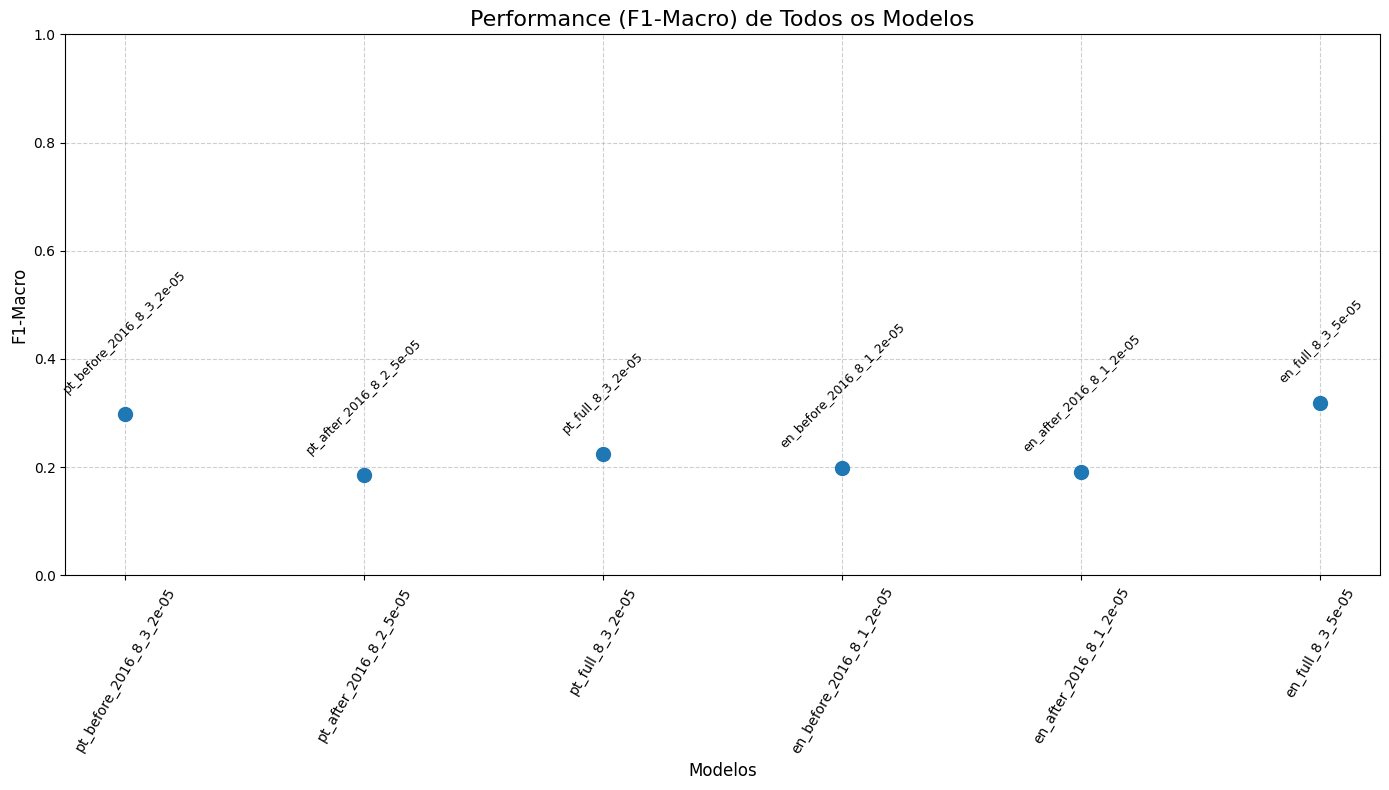

In [5]:
plt.figure(figsize=(14, 8)) 

plt.scatter(x=df.index, y=df['test_f1_macro'], s=100, zorder=5)

for i, name in enumerate(df['model_name']):
    plt.annotate(name,
                 (df.index[i], df['test_f1_macro'][i]),
                 textcoords="offset points",
                 xytext=(0, 15),
                 ha='center',
                 fontsize=9, 
                 rotation=45)

plt.title('Performance (F1-Macro) de Todos os Modelos', fontsize=16)
plt.xlabel('Modelos', fontsize=12)
plt.ylabel('F1-Macro', fontsize=12)
plt.ylim(0, 1)
plt.xticks(ticks=df.index, labels=df['model_name'], rotation=60, ha='center')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

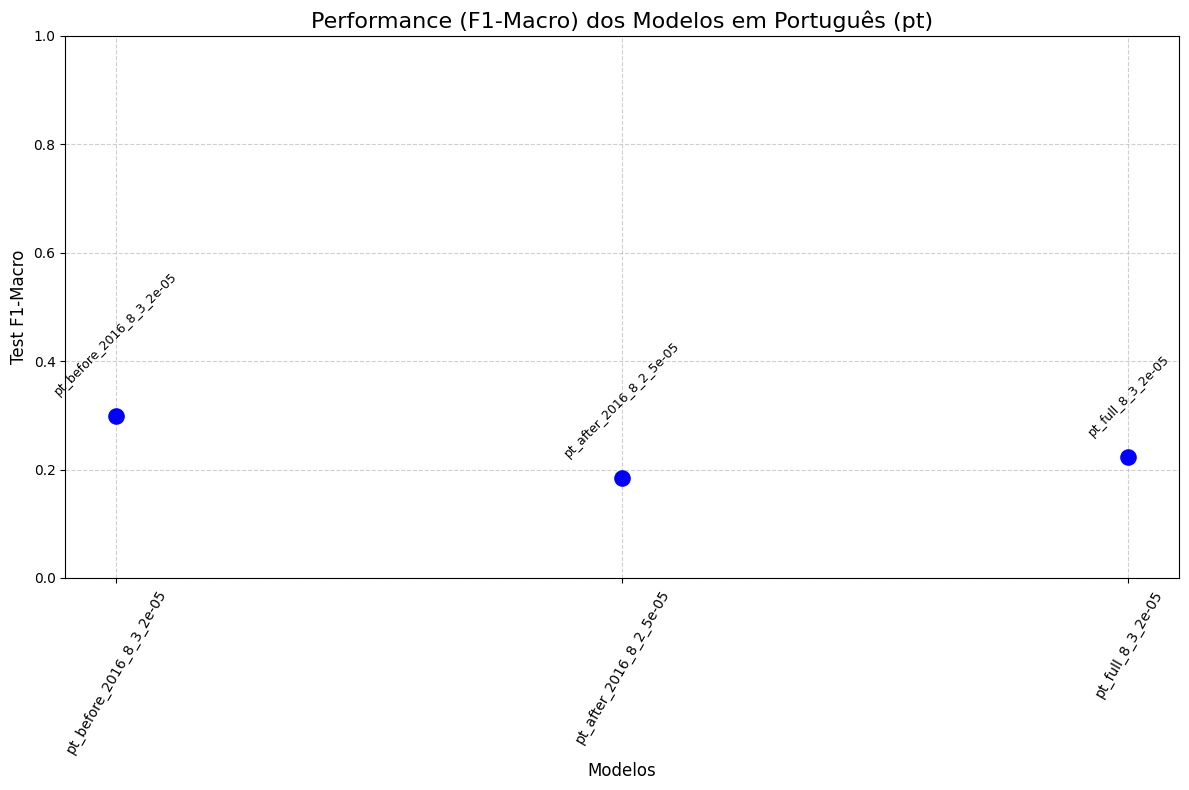

In [6]:
df_pt = df[df['language'] == 'pt'].reset_index(drop=True)

plt.figure(figsize=(12, 8)) 

plt.scatter(x=df_pt.index, y=df_pt['test_f1_macro'], s=120, color='blue', zorder=5)

for i, name in enumerate(df_pt['model_name']):
    plt.annotate(name,
                 (df_pt.index[i], df_pt['test_f1_macro'][i]),
                 textcoords="offset points",
                 xytext=(0, 15),
                 ha='center',
                 rotation=45,
                 fontsize=9)

plt.title('Performance (F1-Macro) dos Modelos em Português (pt)', fontsize=16)
plt.xlabel('Modelos', fontsize=12)
plt.ylabel('Test F1-Macro', fontsize=12)
plt.ylim(0, 1)

plt.xticks(ticks=df_pt.index, labels=df_pt['model_name'], rotation=60, ha='center')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

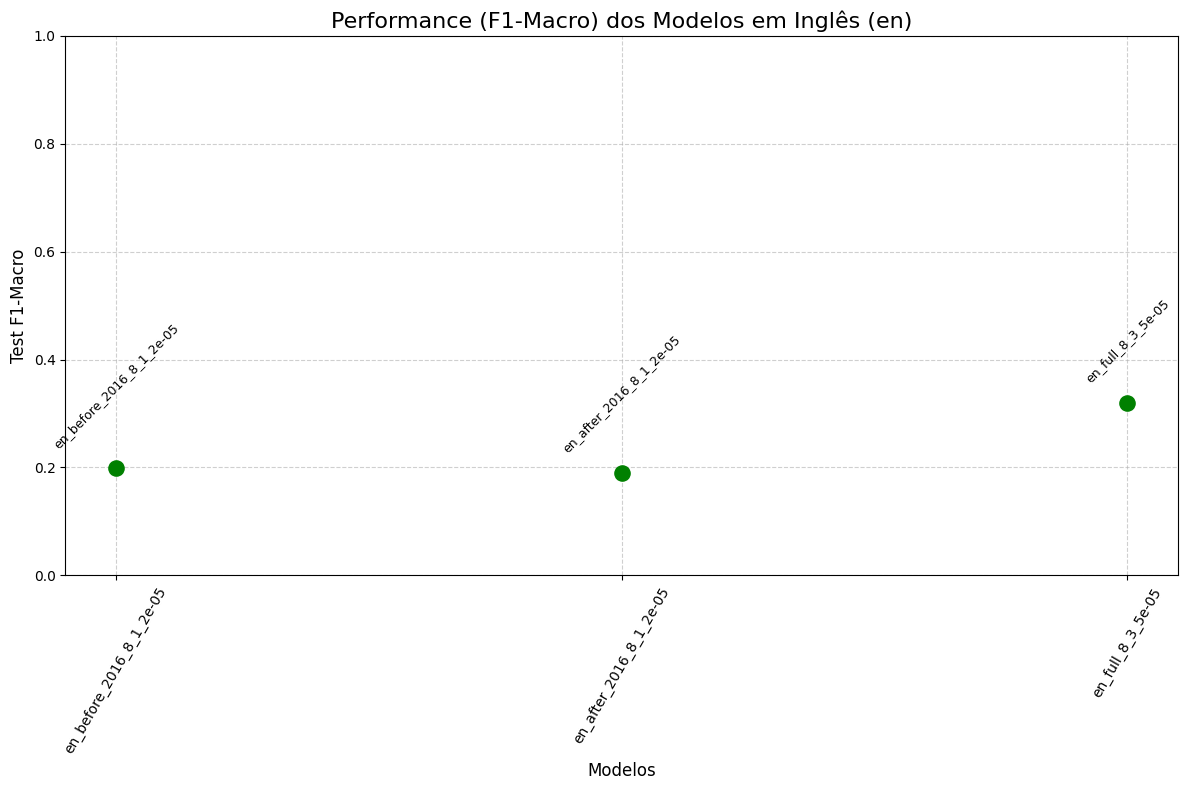

In [7]:
df_en = df[df['language'] == 'en'].reset_index(drop=True)

plt.figure(figsize=(12, 8))

plt.scatter(x=df_en.index, y=df_en['test_f1_macro'], s=120, color='green', zorder=5)

for i, name in enumerate(df_en['model_name']):
    plt.annotate(name,
                 (df_en.index[i], df_en['test_f1_macro'][i]),
                 textcoords="offset points",
                 xytext=(0, 15),
                 ha='center',
                 rotation=45,
                 fontsize=9)

plt.title('Performance (F1-Macro) dos Modelos em Inglês (en)', fontsize=16)
plt.xlabel('Modelos', fontsize=12)
plt.ylabel('Test F1-Macro', fontsize=12)
plt.ylim(0, 1)

plt.xticks(ticks=df_en.index, labels=df_en['model_name'], rotation=60, ha='center')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()